In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('world_cup.csv')

In [8]:
df.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [9]:
df.shape

(22, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           22 non-null     int64 
 1   Host           22 non-null     object
 2   Teams          22 non-null     int64 
 3   Champion       22 non-null     object
 4   Runner-Up      22 non-null     object
 5   TopScorrer     22 non-null     object
 6   Attendance     22 non-null     int64 
 7   AttendanceAvg  22 non-null     int64 
 8   Matches        22 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 1.7+ KB


In [12]:
df.describe().round()

,Year,Teams,Attendance,AttendanceAvg,Matches
count,22.0,22.0,22.0,22.0,22.0
mean,1979.0,22.0,2002201.0,42729.0,44.0
std,28.0,7.0,1101740.0,12137.0,18.0
min,1930.0,13.0,363000.0,20872.0,17.0
25%,1959.0,16.0,931190.0,34749.0,32.0
50%,1980.0,20.0,1987738.0,46705.0,45.0
75%,2001.0,32.0,2999695.0,49527.0,64.0
max,2022.0,32.0,3587538.0,68991.0,64.0


In [13]:
df.isnull().sum()

Year             0
Host             0
Teams            0
Champion         0
Runner-Up        0
TopScorrer       0
Attendance       0
AttendanceAvg    0
Matches          0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.corr(numeric_only = True)

,Year,Teams,Attendance,AttendanceAvg,Matches
Year,1.000000,0.909313,0.952786,0.709427,0.970050
Teams,0.909313,1.000000,0.891888,0.529207,0.949637
Attendance,0.952786,0.891888,1.000000,0.832537,0.942897
AttendanceAvg,0.709427,0.529207,0.832537,1.000000,0.635957
Matches,0.970050,0.949637,0.942897,0.635957,1.000000


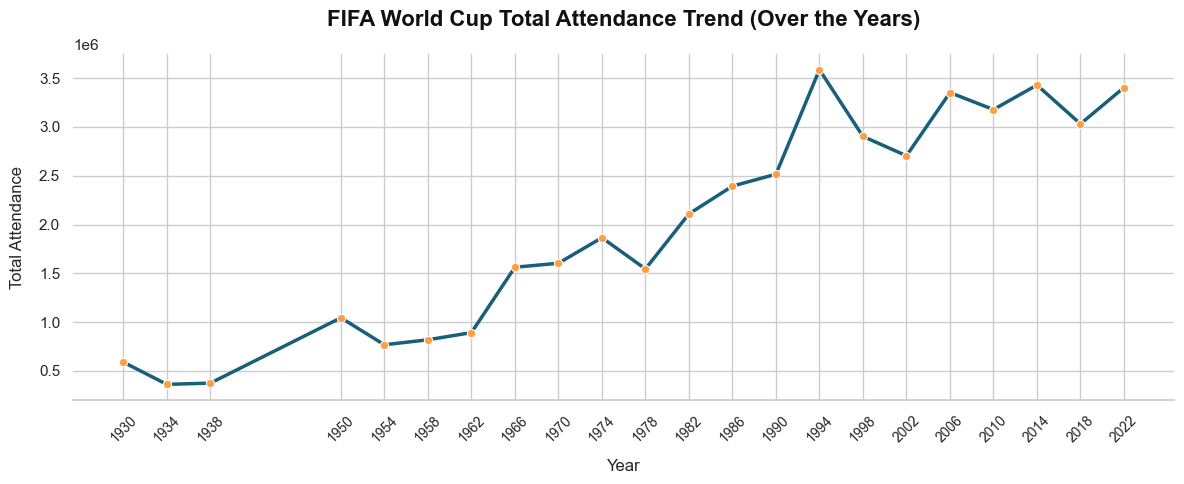

In [50]:
df_chronological = df.sort_values(by='Year')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

sns.lineplot(x='Year', y='Attendance', data=df_chronological, marker='o', linewidth=2.5, color='#1a5f7a', markersize=6, markerfacecolor='#ff9f43')

sns.despine(left=True, bottom=False, top=True, right=True)

plt.title('FIFA World Cup Total Attendance Trend (Over the Years)', fontsize=16, fontweight='bold', pad=20, color='#111111')
plt.xlabel('Year', fontsize=12, fontweight='medium', labelpad=10)
plt.ylabel('Total Attendance', fontsize=12, fontweight='medium', labelpad=10)
plt.xticks(df_chronological['Year'], rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
top_champions = df['Champion'].value_counts().reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_17516\3793662117.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


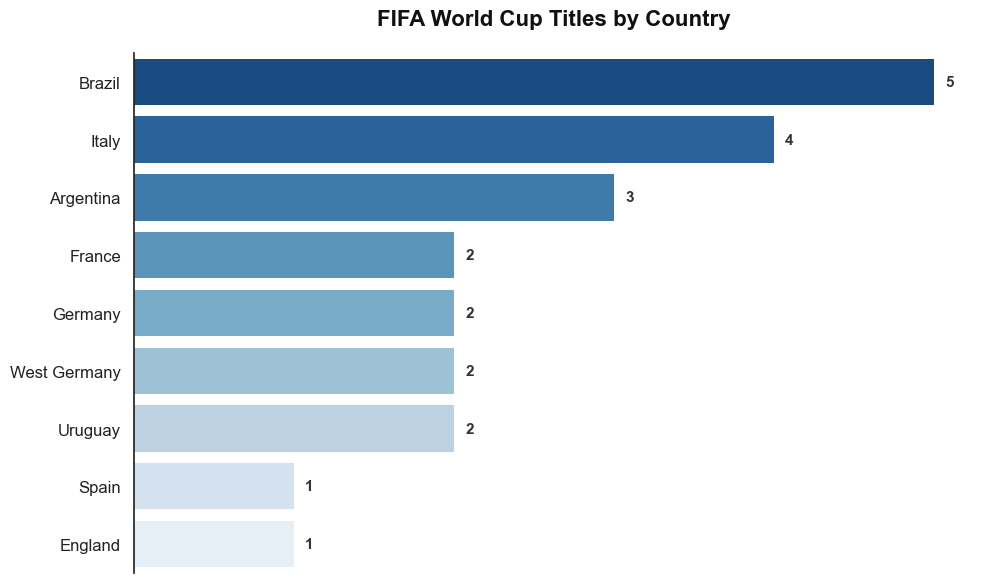

In [30]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

ax = sns.barplot(x='count', y='Champion', data=top_champions, palette='Blues_r', edgecolor='none')

sns.despine(left=False, bottom=True, top=True, right=True)

for container in ax.containers:
    ax.bar_label(container, padding=8, fontsize=11, fontweight='semibold', color='#333333')

plt.title('FIFA World Cup Titles by Country', fontsize=16, fontweight='bold', pad=20, color='#111111')
plt.xlabel('', fontsize=12)  
plt.ylabel('', fontsize=12)


plt.xticks([]) 
plt.yticks(fontsize=12, fontweight='medium', color='#222222')
plt.tight_layout()
plt.show()

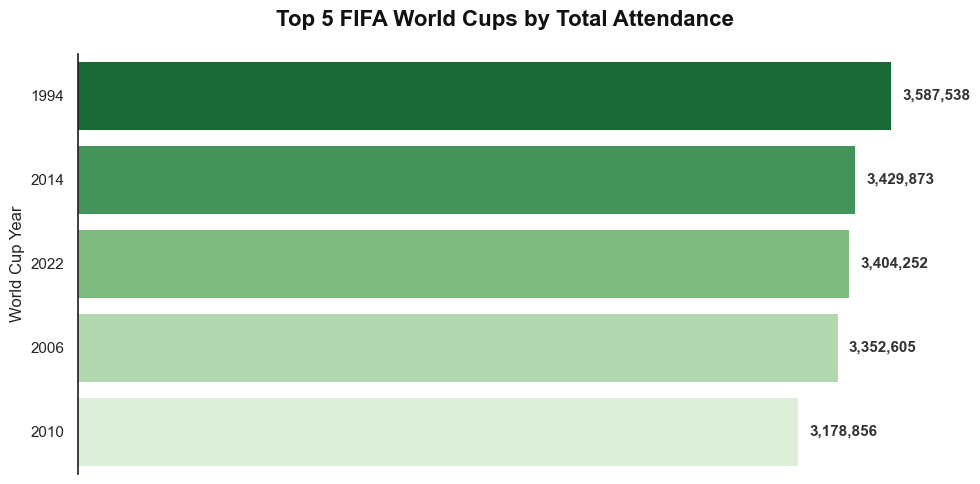

In [39]:
top_5_attendance = df.sort_values(by='Attendance', ascending=False).head(5)

sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x='Attendance', 
    y=top_5_attendance['Year'].astype(str), 
    data=top_5_attendance, 
    palette='Greens_r',
    hue=top_5_attendance['Year'].astype(str),
    legend=False,
    edgecolor='none'
)

sns.despine(left=False, bottom=True, top=True, right=True)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=8, fontsize=11, fontweight='semibold', color='#333333')

plt.title('Top 5 FIFA World Cups by Total Attendance', fontsize=16, fontweight='bold', pad=20, color='#111111')
plt.xlabel('')
plt.ylabel('World Cup Year', fontsize=12, fontweight='medium')
plt.tight_layout()
plt.show()

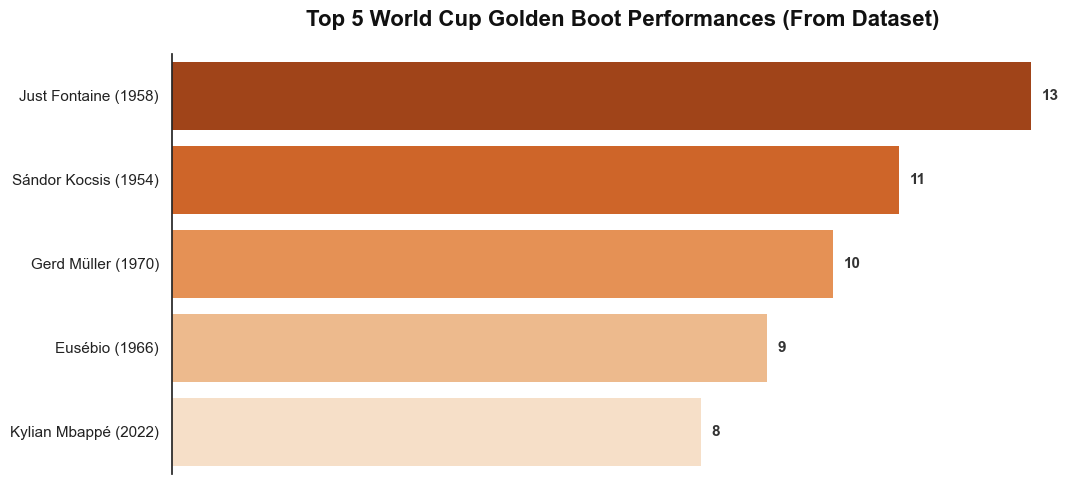

In [45]:
df['Goals'] = df['TopScorrer'].str.split(' - ').str[-1].astype(int)
df['Player_Name'] = df['TopScorrer'].str.split(' - ').str[0]

top_5_scorers = df.sort_values(by='Goals', ascending=False).head(5)
top_5_scorers['Player_Year'] = top_5_scorers['Player_Name'] + ' (' + top_5_scorers['Year'].astype(str) + ')'

sns.set_theme(style="white")
plt.figure(figsize=(11, 5))

ax = sns.barplot(x='Goals', y='Player_Year', data=top_5_scorers, palette='Oranges_r', hue='Player_Year', legend=False, edgecolor='none')
for container in ax.containers:
    ax.bar_label(container, padding=8, fontsize=11, fontweight='semibold', color='#333333')

sns.despine(left=False, bottom=True, top=True, right=True)

plt.title('Top 5 World Cup Golden Boot Performances (From Dataset)', fontsize=16, fontweight='bold', pad=20, color='#111111')
plt.xlabel('')
plt.ylabel('')
plt.xticks([]) 
plt.yticks(fontsize=11, fontweight='medium', color='#222222')

plt.tight_layout()
plt.show()

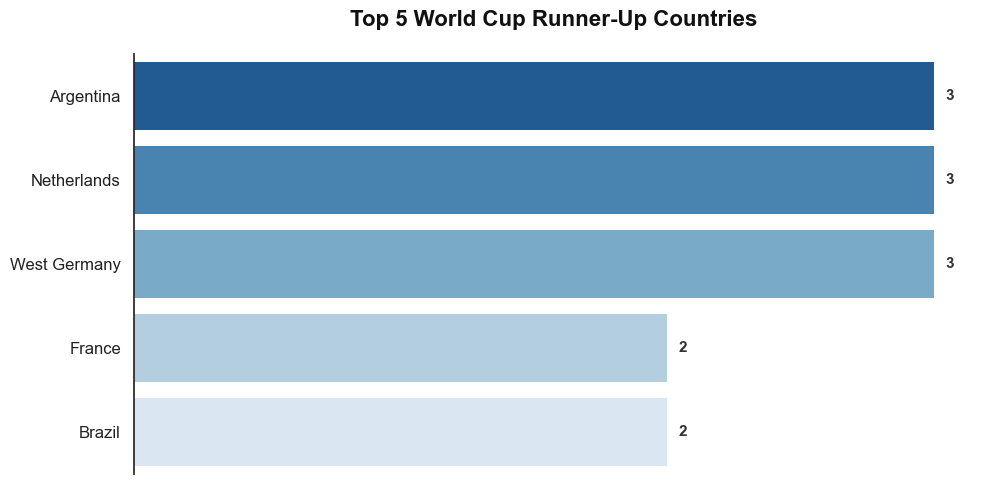

In [47]:
top_5_runners_up = df['Runner-Up'].value_counts().reset_index().head(5)

sns.set_theme(style="white")
plt.figure(figsize=(10, 5))


ax = sns.barplot(x='count', y='Runner-Up', data=top_5_runners_up, palette='Blues_r', hue='Runner-Up', legend=False, edgecolor='none')

for container in ax.containers:
    ax.bar_label(container, padding=8, fontsize=11, fontweight='semibold', color='#333333')

sns.despine(left=False, bottom=True, top=True, right=True)

plt.title('Top 5 World Cup Runner-Up Countries', fontsize=16, fontweight='bold', pad=20, color='#111111')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks(fontsize=12, fontweight='medium', color='#222222')

plt.tight_layout()
plt.show()